# 01 — Exploratory Data Analysis

This notebook analyses the training data to understand:
- Row counts, columns, and missing values
- Country distribution
- Name and address length distributions
- Ground-truth match statistics
- Singleton percentage

In [1]:
import sys
sys.path.insert(0, '../src')

from business_entity_resolution.config import load_config
from business_entity_resolution.data_loader import load_train_data
from business_entity_resolution.preprocessing import preprocess_sources
from business_entity_resolution.ground_truth import parse_ground_truth

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
cfg = load_config('../config.yaml')

In [2]:
data = load_train_data(cfg)
data = preprocess_sources(data, cfg)

print('Source 1:', data.source1.shape)
print('Source 2:', data.source2.shape)
print('Source 3:', data.source3.shape)

Source 1: (2206821, 10)
Source 2: (5034616, 10)
Source 3: (5285603, 10)


In [3]:
# Missing values
for name, df in [('S1', data.source1), ('S2', data.source2), ('S3', data.source3)]:
    print(f'\n--- {name} Missing Values ---')
    print(df.isnull().sum())


--- S1 Missing Values ---


entity_id                      0
business_name                  0
business_address               0
country                        0
business_name_normalized       0
business_address_normalized    0
country_normalized             0
postal_code                    0
house_number                   0
address_numeric_tokens         0
dtype: int64

--- S2 Missing Values ---


entity_id                      0
business_name                  0
business_address               0
country                        0
business_name_normalized       0
business_address_normalized    0
country_normalized             0
postal_code                    0
house_number                   0
address_numeric_tokens         0
dtype: int64

--- S3 Missing Values ---


entity_id                      0
business_name                  0
business_address               0
country                        0
business_name_normalized       0
business_address_normalized    0
country_normalized             0
postal_code                    0
house_number                   0
address_numeric_tokens         0
dtype: int64


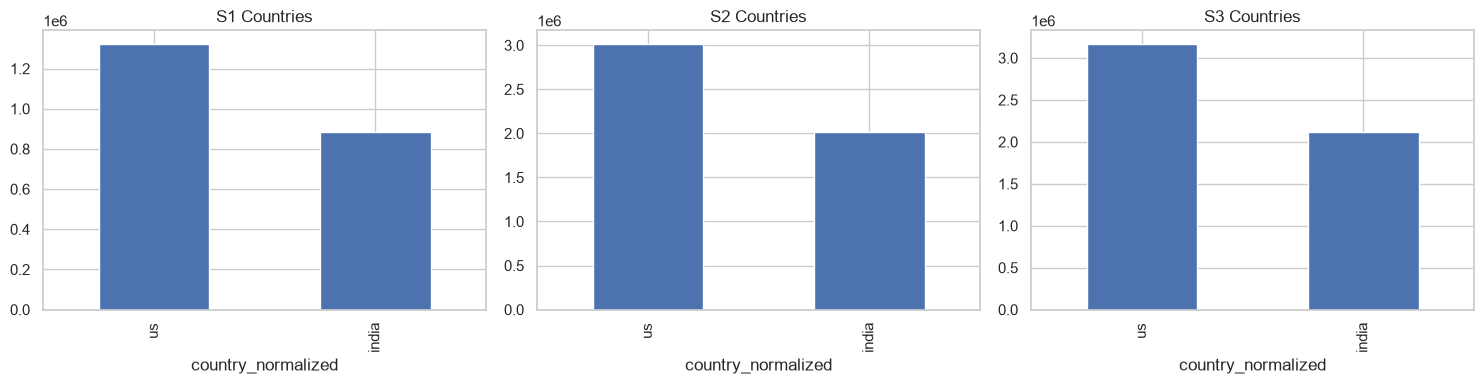

In [4]:
# Country distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, df) in zip(axes, [('S1', data.source1), ('S2', data.source2), ('S3', data.source3)]):
    df['country_normalized'].value_counts().plot(kind='bar', ax=ax, title=f'{name} Countries')
plt.tight_layout()
plt.show()

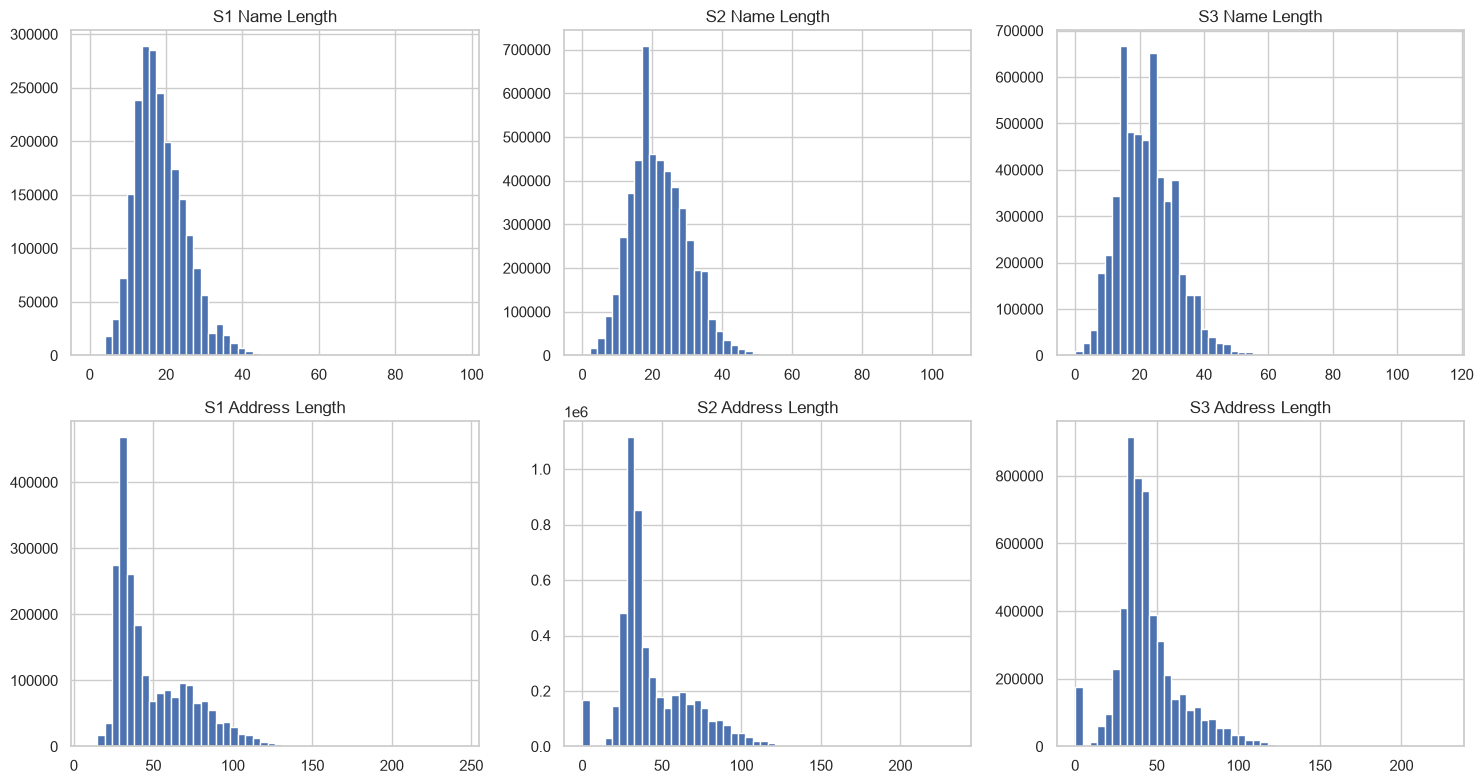

In [5]:
# Name and address length distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col_idx, (name, df) in enumerate([('S1', data.source1), ('S2', data.source2), ('S3', data.source3)]):
    df['business_name_normalized'].str.len().hist(bins=50, ax=axes[0, col_idx])
    axes[0, col_idx].set_title(f'{name} Name Length')
    df['business_address_normalized'].str.len().hist(bins=50, ax=axes[1, col_idx])
    axes[1, col_idx].set_title(f'{name} Address Length')
plt.tight_layout()
plt.show()

Total S1 entities: 2206821
Singletons: 123247
With matches: 2083574
Max matches: 11
Mean matches: 3.46


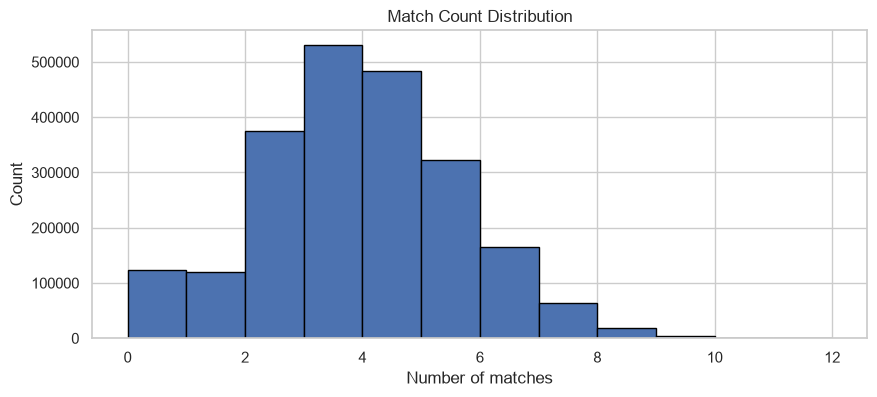

In [6]:
# Ground truth analysis
gt_map = parse_ground_truth(data.ground_truth)
match_counts = [len(v) for v in gt_map.values()]

print(f'Total S1 entities: {len(gt_map)}')
print(f'Singletons: {sum(1 for c in match_counts if c == 0)}')
print(f'With matches: {sum(1 for c in match_counts if c > 0)}')
print(f'Max matches: {max(match_counts)}')
print(f'Mean matches: {sum(match_counts)/len(match_counts):.2f}')

plt.figure(figsize=(10, 4))
plt.hist(match_counts, bins=range(max(match_counts)+2), edgecolor='black')
plt.xlabel('Number of matches')
plt.ylabel('Count')
plt.title('Match Count Distribution')
plt.show()